This Jupyter Notebook is for running mirror QA benchmarking process topologically, using the refactored class structure on Rigetti's square lattice devices. Since it's using totally different SDK and execution method from Qiskit SDK, lots of revision was needed.

But it's so much fun! 

To access to Rigetti's Forest SDK, which contains the compiler and Quantum Virtual Machine instances, we need to open up the local server.

Open up Terminal below, and activate any virtual environment of your choice which includes the pre-installed quilc, qvm and pyquil.

```bash
(base) astrydpark@Astryds-MacBook-Pro qiskit-device-benchmarking % conda activate rigetti
(rigetti) astrydpark@Astryds-MacBook-Pro qiskit-device-benchmarking % quilc -P -S

(base) astrydpark@Astryds-MacBook-Pro qiskit-device-benchmarking % conda activate rigetti
(rigetti) astrydpark@Astryds-MacBook-Pro qiskit-device-benchmarking % qvm -S
```
After this, there must be two Terminal tabs running in the background.

CAVEAT: Turn off the Airplay Receiver toggle underneath System Settings > General > Airplay & Handoff on macOS BEFORE running the second command. Otherwise, port 5000 will collide and QVM will fail to execute.

In [6]:
# Now, let's import pyquil's basic modules.
from pyquil import Program, get_qc
from pyquil.gates import *
from pyquil.quilbase import Declare

In [9]:
# construct the Bell State program
p = Program(
    Declare("ro", "BIT", 2),
    H(0),
    CNOT(0, 1),
    MEASURE(0, ("ro", 0)),
    MEASURE(1, ("ro", 1)),
).wrap_in_numshots_loop(10)

# run the program on a QVM
qc = get_qc('9q-square-qvm')
result = qc.run(qc.compile(p)).get_register_map().get("ro")

In [10]:
print(result[0])

[1 1]


In [11]:
print(result[1])

[0 0]


# Changed direction: `AerSimulator` with customised connectivity graph

This is inspired by Rigetti's 9-qubit Novera device, which is a square lattice layout.

```
0 - 1 - 2
|   |   |
3 - 4 - 5
|   |   |
6 - 7 - 8
```

In [1]:
from qiskit_aer import AerSimulator
import networkx as nx

In [4]:
from qiskit import QuantumCircuit, generate_preset_pass_manager
from qiskit.circuit.library import CXGate, HGate, RXGate, RYGate
from qiskit.transpiler import Target, CouplingMap

In [ ]:
# Make a customised coupling map
# CouplingMap.from_grid(3, 3, bidirectional=True) also leads to the same result.
cmap = CouplingMap([[0, 1],
                    [1, 2],
                    [0, 3],
                    [1, 4],
                    [2, 5],
                    [3, 4],
                    [4, 5],
                    [3, 6],
                    [4, 7],
                    [5, 8],
                    [6, 7],
                    [7, 8]])

cmap.make_symmetric()

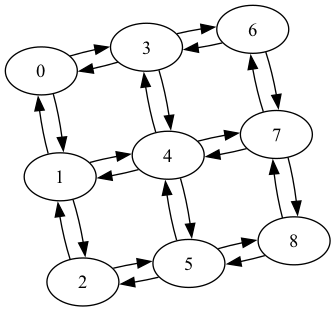

In [12]:
cmap.draw()

In [15]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit.providers.fake_provider import GenericBackendV2

from qiskit_device_benchmarking.bench_code.mrb import MirrorQA, QuantumAwesomeness

In [16]:
# Define connectivity: This represents a square lattice of 9 qubits.
# circ = QuantumCircuit(9)

# custom noisy backend (or an attempt at one, at least)
class NoisyBackend(GenericBackendV2):
    def __init__(
        self,
        num_qubits: int,
        basis_gates: list[str] | None = None,
        coupling_map: list[list[int]] = None,
        p1: float = 0,
        p2: float = 0,
    ):
        self.p = (p1, p2)
        super().__init__(
            num_qubits,
            basis_gates,
            coupling_map=coupling_map,
            noise_info=(p1 > 0 or p2 > 0),
        )

    def _get_noise_defaults(self, name: str, num_qubits: int) -> tuple:
        if name in ["delay", "reset"]:
            return (self.p[0], self.p[0])
        else:
            if num_qubits == 1:
                return (0, 0, self.p[0], self.p[0])
            else:
                return (0, 0, self.p[1], self.p[1])

In [18]:
p = 1e-2

backend = NoisyBackend(
    num_qubits=9, 
    coupling_map=cmap.get_edges(), 
    basis_gates=["id", "h", "x", "y", "z", "rx", "cx"],
    p1=p / 10,
    p2=p,
    )

In [31]:
# number of shots per circuit
shots = 10000

# lengths of different mirror circuits to run
lengths = [2] + [4, 10, 20, 50, 100]

# set up the experiment object
exp = MirrorQA(
    range(backend.num_qubits),
    lengths,
    backend=backend,
    two_qubit_gate_density=0.25, # aim for 1.0 and 0.5 for mirror_qa_topo
    num_samples=20,
    initial_entangling_angle=np.pi / 4,
)
exp.set_run_options(shots=shots)

In [32]:
rb_data = exp.run()
print(rb_data.job_ids)

['2077b3fc-804c-4670-a799-b1aa5a62382e']


In [33]:
print("Pairs:", exp._pairs[0])
# exp._static_trans_circuits[0].draw(fold=-1)

Pairs: [(4, 3), (1, 2)]


In [34]:
exp._static_trans_circuits[0].draw(fold=-1)

global phase: 3π/2
              ░    ┌───┐                     ░       ░    ┌───┐                      ░ ┌───┐ ░  ░ ┌─┐                        
   q_0: ──────░────┤ Z ├─────────────────────░───────░────┤ Z ├──────────────────────░─┤ X ├─░──░─┤M├────────────────────────
        ┌───┐ ░    └───┘    ┌─────────┐      ░       ░    └───┘                      ░ ├───┤ ░  ░ └╥┘┌─┐                     
   q_1: ┤ X ├─░──────■──────┤ Rx(π/4) ├──────░───────░──────■────────────────────────░─┤ X ├─░──░──╫─┤M├─────────────────────
        ├───┤ ░    ┌─┴─┐    └─────────┘      ░ ┌───┐ ░    ┌─┴─┐                      ░ └───┘ ░  ░  ║ └╥┘┌─┐                  
   q_2: ┤ Y ├─░────┤ X ├─────────────────────░─┤ Z ├─░────┤ X ├──────────────────────░───────░──░──╫──╫─┤M├──────────────────
        ├───┤ ░    ├───┤                     ░ ├───┤ ░    ├───┤                      ░ ┌───┐ ░  ░  ║  ║ └╥┘┌─┐               
   q_3: ┤ X ├─░────┤ X ├─────────────────────░─┤ Y ├─░────┤ X ├──────────────────────░─┤ Y ├─░──░──╫──╫──╫─┤M├───────────────
        ├───┤ ░    └─┬─┘    ┌─────────┐      ░ ├───┤ ░    └─┬─┘                      ░ ├───┤ ░  ░  ║  ║  ║ └╥┘┌─┐            
   q_4: ┤ X ├─░──────■──────┤ Rx(π/4) ├──────░─┤ Y ├─░──────■────────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫─┤M├────────────
        ├───┤ ░ ┌─────────┐ └──┬───┬──┘┌───┐ ░ ├───┤ ░    ┌───┐    ┌──────────┐┌───┐ ░ └───┘ ░  ░  ║  ║  ║  ║ └╥┘┌─┐         
   q_5: ┤ Y ├─░─┤ Rx(π/2) ├────┤ H ├───┤ Z ├─░─┤ Y ├─░────┤ H ├────┤ Rx(-π/2) ├┤ X ├─░───────░──░──╫──╫──╫──╫──╫─┤M├─────────
        ├───┤ ░ ├─────────┤    ├───┤   ├───┤ ░ ├───┤ ░    ├───┤    ├──────────┤├───┤ ░ ┌───┐ ░  ░  ║  ║  ║  ║  ║ └╥┘┌─┐      
   q_6: ┤ X ├─░─┤ Rx(π/2) ├────┤ H ├───┤ Y ├─░─┤ Y ├─░────┤ H ├────┤ Rx(-π/2) ├┤ Z ├─░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫─┤M├──────
        ├───┤ ░ └──┬───┬──┘    └───┘   └───┘ ░ ├───┤ ░    ├───┤    └──────────┘└───┘ ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║ └╥┘┌─┐   
   q_7: ┤ Y ├─░────┤ Y ├─────────────────────░─┤ X ├─░────┤ Y ├──────────────────────░─┤ Y ├─░──░──╫──╫──╫──╫──╫──╫──╫─┤M├───
        └───┘ ░ ┌──┴───┴───┐   ┌───┐         ░ └───┘ ░ ┌──┴───┴───┐                  ░ ├───┤ ░  ░  ║  ║  ║  ║  ║  ║  ║ └╥┘┌─┐
   q_8: ──────░─┤ Rx(-π/2) ├───┤ X ├─────────░───────░─┤ Rx(-π/2) ├──────────────────░─┤ X ├─░──░──╫──╫──╫──╫──╫──╫──╫──╫─┤M├
              ░ └──────────┘   └───┘         ░       ░ └──────────┘                  ░ └───┘ ░  ░  ║  ║  ║  ║  ║  ║  ║  ║ └╥┘
meas: 9/═══════════════════════════════════════════════════════════════════════════════════════════╩══╩══╩══╩══╩══╩══╩══╩══╩═
                                                                                                   0  1  2  3  4  5  6  7  8

In [42]:
exp.analysis.set_options(analyzed_quantity="Effective Polarization")
# exp.analysis.set_options(analyzed_quantity='Mutual Information')
analysis = exp.analysis.run(rb_data)

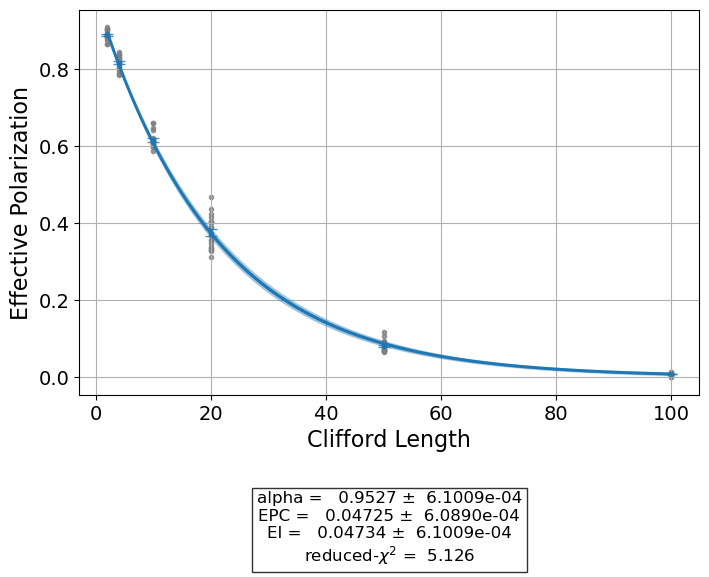

In [43]:
analysis.figure(0)

In [38]:
# Mutual Intormation calculated by QuantumAwesomeness class

qa = QuantumAwesomeness(exp.backend.coupling_map)

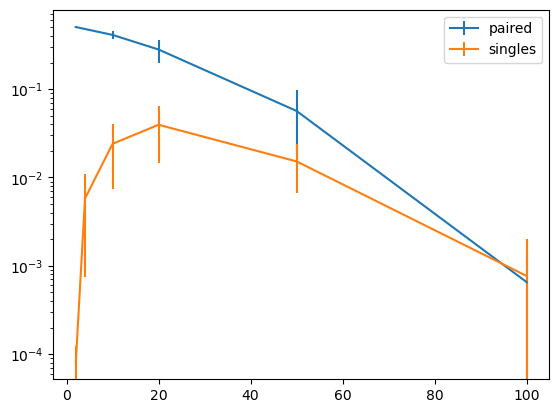

In [39]:
mi = qa.mutual_info(rb_data.data())

mmi = qa.mean_mutual_info(rb_data.data(), exp._pairs)

ys = [[[] for _ in range(6)] for _ in range(2)]
yerrs = [[], []]

for p, pairtype in enumerate(["paired", "singles"]):
    for j, m in enumerate(mmi[pairtype]):
        if m is not np.nan:
            ys[p][j % 6].append(m)
    for j in range(6):
        yerrs[p].append(np.std(ys[p][j]))
        ys[p][j] = np.mean(ys[p][j])

plt.errorbar(lengths, ys[0], yerr=yerrs[0], label="paired")
plt.errorbar(lengths, ys[1], yerr=yerrs[1], label="singles")
plt.yscale("log")
plt.legend()